In [1]:
import sys
from pathlib import Path

root_path = Path.cwd().parent.parent

sys.path.append(str(root_path))
params_path = root_path / "params/"

import datetime

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from plotting.plot_style import lighten_color, plot_style

In [2]:
file_path = root_path / "data/"

In [3]:
frequency_data = pd.read_csv(file_path / "frequency_london.csv")

In [4]:
frequency_data

,time_stamp,frequency
0,2025-08-01 00:00:00.000,49.9629
1,2025-08-01 00:00:00.100,49.9626
2,2025-08-01 00:00:00.200,49.9626
3,2025-08-01 00:00:00.300,49.9629
4,2025-08-01 00:00:00.400,49.9629
...,...,...
26783995,2025-08-31 23:59:59.500,50.1040
26783996,2025-08-31 23:59:59.600,50.1036
26783997,2025-08-31 23:59:59.700,50.1035
26783998,2025-08-31 23:59:59.800,50.1035


In [5]:
frequency_data["omega"] = 2 * np.pi * (frequency_data["frequency"] - 50)

# Aggregated time series

In [6]:
# Aggregating data

frequency_data["time_stamp"] = pd.to_datetime(frequency_data["time_stamp"])
frequency_data["time_of_day"] = frequency_data["time_stamp"].dt.time

frequency_aggregated = (
    frequency_data.groupby("time_of_day")["omega"].agg(["mean", "std"]).reset_index()
)
frequency_aggregated.columns = ["time_of_day", "omega_mean", "omega_std"]

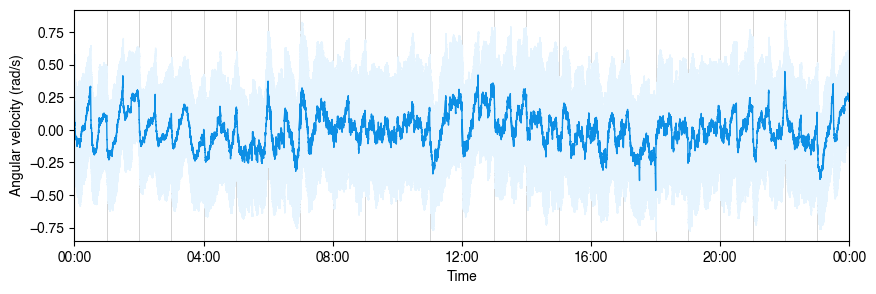

In [7]:
# Conversion to datetime format for plot
base_date = datetime.date(2025, 8, 1)
frequency_aggregated["datetime"] = frequency_aggregated["time_of_day"].apply(
    lambda t: datetime.datetime.combine(base_date, t)
)
time_stamp_start = frequency_data["time_stamp"][0]
time_stamp_end = frequency_data["time_stamp"][len(frequency_aggregated)]

with plot_style():

    fig, ax = plt.subplots(1, 1, figsize=(10, 3))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    ax.plot(
        frequency_aggregated["datetime"],
        frequency_aggregated["omega_mean"],
        lw=1.0,
        color=colors[0],
    )

    ax.fill_between(
        frequency_aggregated["datetime"],
        frequency_aggregated["omega_mean"] - frequency_aggregated["omega_std"],
        frequency_aggregated["omega_mean"] + frequency_aggregated["omega_std"],
        color=lighten_color(colors[0], 0.1),
        alpha=1.0,
    )

    # Hourly lines.
    hourly_ticks = np.arange(time_stamp_start, time_stamp_end, dtype="datetime64[h]")
    for t in hourly_ticks:
        ax.axvline(
            t, color="darkgray", linestyle="solid", alpha=0.7, lw=0.5, zorder=-100
        )

    ax.set_xlim(time_stamp_start, time_stamp_end)

    ax.xaxis.set_major_locator(mdates.HourLocator(byhour=np.arange(0, 24, 4)))
    formatter = mdates.DateFormatter("%H:%M")
    ax.xaxis.set_major_formatter(formatter)

    ax.set_ylabel("Angular velocity (rad/s)")
    ax.set_xlabel("Time")

    plt.show()

# Distribution

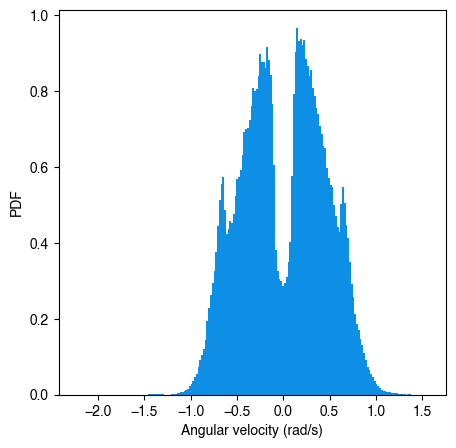

In [8]:
with plot_style():

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    ax.hist(frequency_data["omega"], bins=200, density=True)

    ax.set_xlabel("Angular velocity (rad/s)")
    ax.set_ylabel("PDF")

    plt.show()